In [ ]:
!pip -q install langchain-core langchain-community langgraph langchain-openai duckduckgo-search

## Traditional ReAct


react_prompt = """Assistant is a large language model trained by Microsoft.

Assistant is designed to be able to assist with a wide range of tasks, from answering simple questions to providing in-depth explanations and discussions on a wide range of topics. As a language model, Assistant is able to generate human-like text based on the input it receives, allowing it to engage in natural-sounding conversations and provide responses that are coherent and relevant to the topic at hand.

Assistant is constantly learning and improving, and its capabilities are constantly evolving. It is able to process and understand large amounts of text, and can use this knowledge to provide accurate and informative responses to a wide range of questions. Additionally, Assistant is able to generate its own text based on the input it receives, allowing it to engage in discussions and provide explanations and descriptions on a wide range of topics.

Overall, Assistant is a powerful tool that can help with a wide range of tasks and provide valuable insights and information on a wide range of topics. Whether you need help with a specific question or just want to have a conversation about a particular topic, Assistant is here to assist.

TOOLS:
------

Assistant has access to the following tools:

wikipedia_search - searches the wikipedia database for the answer\n
web_search - searches the web for the answer\n
calculator - calculates the answer to the question\n
weather_api - gets the weather for the location\n


To use a tool, please use the following format:

```
Thought: Do I need to use a tool? Yes
Action: the action to take, should be one of [wikipedia_search, web_search, calculator, weather_api]
Action Input: the input to the action
Observation: the result of the action
```

When you have a response to say to the Human, or if you do not need to use a tool, you MUST use the format:

```
Thought: Do I need to use a tool? No
Final Answer: [your response here]
```

Begin!


New input: Whow was King Arthur?
"""

In [ ]:
!pip install python-dotenv

In [ ]:
!pip install -q -U langchain-google-genai

In [ ]:
!pip install -U langchain langchain-community langchain-google-genai pydantic tenacity


In [1]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GEMINI_API_KEY")
)

# Test
response = llm.invoke("Hey Buddy")
print(response.content)

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Hey there! How can I help you today, buddy?


## Tools

In [2]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.

    Args:
        a: first int
        b: second int
    """

    return a*b

def add(a: int, b: int) -> int:
    """
    adds a and b.

    Args:
        a: first int
        b: second int
    """

    return a+b

def divide(a: int, b: int) -> float:
    """
    Divide a and b.

    Args:
        a: first int
        b: second int
    """

    return a/b

In [3]:
# Search Tool
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("What all are highest earning bollywood movies?")

'Home – Learn – Highest - Earning Bollywood Movies of All Time (2025): A Celebration of Hits ... Highest Grossing Bollywood Movies of all ... Take a look at these 4 Bollywood movies that has grabbed highest earnings . ... This movie became the highest grossing Bollywood film in India. In this countdown of the “ Top 10 Highest Earning bollywood movies of All Time, ” we celebrate the stories that captivated hearts and ... 10: Ek Tha Tiger (US$50 Million) Directed by Kabir Khan Ek Tha Tiger is among the Bollywood highest grossing movies with collective earnings of US$50 ... We are presenting you with the list of top 15 Bollywood Movies which have earned the highest at box office till 2014.'

In [4]:
tools = [add, multiply, divide, search]

llm_with_tools = llm.bind_tools(tools)

In [5]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")


## Nodes

In [6]:
def reasoner(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

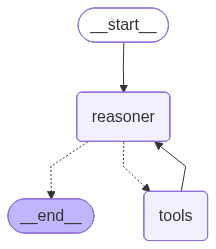

In [7]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display_json

# Graph
builder = StateGraph(MessagesState)

# Add Nodes
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools))

# Add Edges
builder.add_edge(START, "reasoner")
builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "reasoner")

react_graph = builder.compile()

# display graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [8]:
messages = [HumanMessage(content = "What's sum of the age of D.Trump and Modi")]
messages = react_graph.invoke({"messages": messages})

In [9]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's sum of the age of D.Trump and Modi
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (cb926b00-bde4-4d48-8abf-d65356bb1f0b)
 Call ID: cb926b00-bde4-4d48-8abf-d65356bb1f0b
  Args:
    query: Donald Trump age
================================= Tool Message =================================
Name: duckduckgo_search

At 79 years old, Donald Trump , the 47th and previously 45th president of the United States , is the oldest person in American history to be ... Donald Trump Age , Net Worth, Wife, Family, Children and Biography ... Born on 14 June 1946, Donald Trump ’s age is 77 Years Old as of 2023. Before the assassination attempt on Donald Trump that precipitated Elon Musk’s MAGA conversion in the summer of 2024, there was at least one ... Donald Trump , Through the Ages ... The ancestry of Donald Trump stretches back to the Ancient World. ..

In [11]:
# Use astream (async) or stream (sync)
# We filter to only print content from the 'reasoner' node
for message, metadata in react_graph.stream(
    {"messages": [HumanMessage(content="What's difference b/w the age of Trump and Modi?")]},
    stream_mode="messages"
):
    # Only print if the message is coming from the LLM (reasoner)
    # and has text content (this avoids printing raw tool call JSON)
    if metadata["langgraph_node"] == "reasoner" and message.content:
        print(message.content, end="", flush=True)

[{'type': 'text', 'text': 'Donald Trump was born on June 14, 1946, and Narendra Modi was born on September 17, 1950.\n\nDonald Trump is 4 years, 3 months, and 3 days older than', 'extras': {'signature': 'CiIBcsjafOfSxt33SnO/S0Qf571Tx7nivKbtPLr0r1FyZ8/RCoUBAXLI2nwBpTB4vbAyLaufJLBaRyvpdzUX3g8HF2ZWgk2oULqTFES++8zgcWVxkZyjEfUi8mMqAl1AuXLPAer8hKzvpzJKQrxxVaEJRELi1qskbdAuc958q7toD+ZMj/B1BBGj4ahqp7AyCFJe2fDrlvWNSQoS39ceUbU3j/uKzjuFnKif2Qq1AQFyyNp8njwxnhv6/K0x3kNJ8ZXrpHmiN3iwtkpc3Ak+3p6lleODlEQrfFtuAVw4ONv4CbJ+fi6oHGUr0p5J7Dtd51SxxYZtObjhJjK4Muq6Oz7XdKlvP5GMVXtI4Z7P4UGu6szT00C7YBcQVPvAPs4Ptncn4ehxwBmtqHb4zaV/1Kvli2o0h4y0mrW+weQQuxkbKhcAjHtJkrmsTMRVQrdvNJKQ9/Mm2M6OXDGBed4mCA0gMCMKxwEBcsjafKWEMDdjXBQrD7NkpSzDzkUboVbh+bqEL1zli4BYQxy2pgp/4kaxRhwJL1LqixzY63ET/ByWfJRjC1xKjwg8q29BoST5oPDus64CCyrPVnFRbmnju9NZl9VlR8NvG6z6fSzMhqjRksWQoBaHl2+rWuzn/C1pa6rUXNIXpa5/1B3IAtWS6NChf67iiebBpAtZb7oemRoZLBUqVu+1BqChEcyNzUEwvugKQoqC4k4GnkbYKkAN/azy7ifyy+9P646XYSjZCocBAXLI2nzx7Sv4KwYLDpU6ZJBiWqD865PZBaLJzybiKaxx/KsO

In [12]:
for message, metadata in react_graph.stream(inputs, stream_mode="messages"):
    # If the message has tool_calls, the LLM is still 'acting'
    if hasattr(message, "tool_calls") and message.tool_calls:
        continue 
    
    if metadata["langgraph_node"] == "reasoner":
        print(message.content, end="", flush=True)

NameError: name 'inputs' is not defined

In [13]:
# 1. Define the inputs (the starting state)
inputs = {"messages": [HumanMessage(content="What's difference b/w the age of D.Trump and Modi")]}

# 2. Run the stream
# 'stream_mode="messages"' yields (message_chunk, metadata)
for message, metadata in react_graph.stream(inputs, stream_mode="messages"):
    
    # FILTER 1: Only look at tokens from the 'reasoner' node
    if metadata["langgraph_node"] == "reasoner":
        
        # FILTER 2: Skip tool calls (we only want the final text answer)
        if hasattr(message, "tool_calls") and message.tool_calls:
            continue
            
        # Print tokens as they arrive
        if message.content:
            print(message.content, end="", flush=True)

[{'type': 'text', 'text': 'The difference in age between D. Trump and Modi is 4 years.', 'extras': {'signature': 'Ci8BcsjafALDizASZPupD1XGYBHaT/rSSCQaGvPmb+hij309eqcFrQmOD4YJBUcwCApOAXLI2nwNdAamwt9WZZeWF3wbmOB1OQvH/l02PAnQMQAH7C/ixOS7rymVrtSq/Wxv456VvxOR7Bs6WEIAEzinOIGjKQoybQrZF4+v9Btf'}, 'index': 0}]

# Adding Custom Tools

In [10]:
!pip -q install yahoo-finance

In [12]:
!pip install yfinance


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/127.1 kB ? eta -:--:--
   ---------------------------- ----------- 92.2/127.1 kB 1.8 MB/s eta 0:00:01
   -------------------------------------- - 122.9/127.1 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 127.1/127.1 kB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   --- ------------------------------------ 0.1/1.6 MB 7.0 MB/s eta 0:00:01
   -------- ------------------------------- 0.3/1.6 MB 5.2 MB/s eta 0:00:01
   ----------------- ---------------------- 0.7/1.6 MB 6.4 MB/s eta 0:00:01
   ---------------------------- ----------- 1.2/1.6 MB 7.3 MB/s eta 0:00:01
   -------------------------------------- - 1.5/1.6 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/411.9 kB ? eta 

In [13]:
import yfinance as yf


In [14]:
def get_stock_price(ticker: str) -> float:
    """
    Gets a stock price from yahoo

    Args:
        ticker: ticker str
    """

    stock = yf.Ticker(ticker)
    return stock.info["previousClose"]

In [15]:
get_stock_price("AAPL")

259.04

In [16]:
# Node

def reasoner(state):
    query = state["query"]
    messages = state["messages"]
    sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs.")
    message = HumanMessage(content = query)
    messages.append(message)
    result = [llm_with_tools.invoke([sys_msg] + messages)]
    return {"messages": result}

In [17]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GEMINI_API_KEY")
)

In [18]:
tools = [add, multiply, divide, search, get_stock_price]

llm_with_tools = llm.bind_tools(tools)

In [19]:
tools[4]

<function __main__.get_stock_price(ticker: str) -> float>

In [20]:
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class GraphState(TypedDict):
    """state of graph"""
    query: str
    finance: str
    final_answer: str
    messages: Annotated[list[AnyMessage], operator.add]

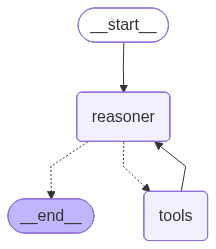

In [21]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition # this is the checker for the
from langgraph.prebuilt import ToolNode

# Graph
workflow = StateGraph(GraphState)

# Add Node
workflow.add_node("reasoner", reasoner)
workflow.add_node("tools", ToolNode(tools))

# Add Edges

workflow.add_edge(START, "reasoner")
workflow.add_conditional_edges("reasoner", tools_condition)
workflow.add_edge("tools", "reasoner")


react_graph = workflow.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [22]:
response = react_graph.invoke({"query": "What's the age of salman khan", "messages": []})

response

{'query': "What's the age of salman khan",
 'messages': [HumanMessage(content="What's the age of salman khan", additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "age of salman khan"}'}, '__gemini_function_call_thought_signatures__': {'b5693b1f-0d79-4cd9-b81b-a16bf638f0a0': 'CtoDAXLI2nz1mYOH/Y6+KhxJVCVtrnFo7Ad7zSizrpQXeDCc803NFSxepzXmTZllwddcBj/Pj1jkZFboGmGMcwyrVwztcIp3BIaV8NbIOxiv/+RzA7KChwXq7s8BBB0cwVYNQXZjvASJed/n1PuyWOikP1v/If+kFeGyNzIMQBO/6Mb5gjnciErTJ7l3R3EZKOaTatf/r+fznQ1yh3aD+2gGfbj5UC6KaYL3n06dC7T/i7VL0sQthBioOJKqRqckr623ihFXCcFdLmCC2yKiEevw92UBQnNAH2LFsh5sFsG/wDhX4ekcmzO6GTOZIyli64r1Q8KshSEZuxwhE4vIWVVpx9mRZO84Nrg3PVxvWCXY1iYczfe3ZBkPkp9hbiViLw+IhscV5HsYBhRFZRY4abNc+DWX4SzIfqucvNCSLaCoNs/dic4EN97/bTdmnXMkDXva+AJzTG5yLo2nJCHx2RPOlxFUhW3gYqGBj9z5/x6+qqhg2/bWgm2axxVTxL2aP1s+8ZFCwDe6cO3zTB+JMXpMNOnEythuR9rQkkuPPReMSktssustG2Gi8KzPGZ8QuDRZ0UOuM5qI/JFQyHIhd7qFeRaQf1GAeA9Xs4N6

In [23]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': 'Salman Khan was born on December 27, 1965, making him 59 years old.', 'extras': {'signature': 'CtUMAXLI2nzstr/BAbwHR5F7fhXIv7pQEJ9TvSaLHy/7rRYbG2FEezHANssjF4iFzV8fD7JpfroN4M1PCvlwejzXR9L/asN40T6+Cy+nvpfndptDT7R6VVxcmstWtyRtDVOGzx2M9Lrm4ydLODzPhFlz7jG8cPBLFTfvVVvhq19GMKvBCkt3YSTQhyMCijRLbL3p7R2HTEKeBg42hLc7/dwmW324K96bgDG2yvylTigGRDysDhqUe8sP7tGPz/pzR/+5obgHpB16SZo6sCkuU2+V5cz5batdaYhcgWHgLQDr6obXeLJuFd0shQvRoYhkN0nUL2LraF0SiKBIUMHSgLXSKt7LNptWaWxsPFwkqlQthDtX1eHcG/NKPwEo0Qo7zNzRrRiHnfB5mbuC0W4fJaT4TgeapJcMu3oBLlFs7eVpygdzgRYKJoiJ+E/OCbQKXmosr9qccKg1mp46rut9ecNKGwecmRqg7wegwJm9ZHMWN2UIplXLYXV5dCnMZ9Eib48nB7sztevVjf0P3ED9KliLxZdTzJ4N6izYLKQsnyWIbZeAdZNynlYHi6b80kgHLuwSJ0uh9VVCCtxBYZMK6aT4VDPeWsVCT4f+t6K2HHNkTE0hg8/VGheIttJx1mICz8dJws/NRWEeLDqPhuy+89zYkGJLG5jaO6PtJp1LnM/MdSoXOMSHT8ssAdbWAhU+pv3f0mO6wjxZF5tDl1/cYJR9lsRBXGA+RMCZoO02uFJl2Ww1A+4DD+Ljxm3ArHHU5tXMkd10ddKR/OAV0PE581gM6BPx

In [ ]:
# response = react_graph.invoke({"query": "How far is tajmhal from new york?", "messages": []})
# messages

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 46.035343522s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT